# Linearna regresija - uvod

## Jednostavna linearna regresija

Statistički metod koji omogućava proučavanje veze između dve kontinualne promenljive.

Prva promenljiva, $x$, se naziva **nezavisna promenljiva**. Druga promenljiva, $y$ se naziva **zavisna promenljiva**.

Jednostavna linearna regresija ima pridev "jednostavna" zato što ima samo jednu nezavisnu promenljivu $x$.
Postoji i višestruka linearna regresija, koja se odnosi na linearnu regresiju sa više nezavisnih promenljivih $x_1, x_2,...x_n$.

Za razliku od jednostavne linearne regresije koja koristi samo jednu prediktorsku promenljivu *x*, višestruka linearna regresija podrazumeva korišćenje dve ili više prediktorskih promenljivih - o ovome više na budućim terminima vežbi.

---
Pre opisa same linearne regresije, važno je napomenuti kakve veze/zavisnosti između promenljivih su od interesa.

**Deterministička (funkcionalna) zavisnost** nam nije od interesa jer njom možemo odrediti **tačnu** vrednost zavisne promenljive $y$ na osnovu vrednosti nezavisne promenljive $x$. Primer: konvertovanje mernih jedinica temperature između stepeni celzijusa i farenhajta:

$ \text{Fahr} = \frac{9}{5} * \text{Cels} + 32 $

![](img/celcius_fahr_plot.gif)

Znajući temperaturu u stepenima celzijusa, možemo iskoristiti prethodnu jednačinu da **tačno** odredimo temperaturu u farenhajtima. Još primera determinističke zavisnosti:

* $ \text{obim} = 2 \pi * \text{poluprecnik} $
* Omov zakon: $ \text{I} = \frac{V}{R} $
* Hukov zakon: $ \text{F} = -\text{k}\text{x} $


Za svaku od ovih determinističkih zavisnosti, jednačina tačno opisuje odnos dve promenljive. Ne razmatramo determinističke veze, već  **statističku zavisnost**, gde veza između dve promenljive nije savršeno tačna.

Primer statističke zavisnosti je određivanje stope smrtnosti od raka kože (broj smrti na 10 miliona ljudi) na osnovu geografske širine centra svake od 49 država u SAD ([skincancer.csv](data/skincancer.csv))

Može se pretpostaviti da u zemljama koje su severnije, ljudi su manje izloženi sunčevoj svetlosti i štetnim uticajima sunčevih zraka (UV zračenja) i samim tim bi rizik smrti od raka kože trebalo biti manji. Dole prikazani grafik podržava takvu hipotezu - vidi se negativna linerna zavisnost između geografske širine i stope smrtnosti od raka kože, ali ova veza nije savršeno linearna. Dakle, ovo je statistička zavisnost, a ne deterministička.

![](img/scatterplot_skin_cancer.png)

Još neki primeri statističke zavisnosti su:

* Visina i težina ljudi - uglavnom očekujemo da su više osobe teže, ali ne mora nužno biti tako
* Kapacitet pluća i količina konzumiranih cigara tokom života - kako se količina konzumiranih cigara povećava, očekuje se smanjenje kapaciteta pluća
* Broj ljudi u prostoriji i temperatura/vlažnost prostorije
* Količina uloženog truda tokom studiranja (kako ovo izmeriti?) i prolaznost / prosek ocena

---


## Koja je "najpogodnija linija"?

Pošto je neophodno pronaći nekakvu linearnu zavisnost između dve promenljive, nameće se pitanje koja je to najpogodnija linija koja opisuje tu zavisnost? U principu, zanima nas da pronađemo liniju $ \hat{y} = a x + b $ koja na najbolji način opisuje date podatke. Podaci su dati kao:

* $ x_i $ - vrednost nezavisne promenljive za svako merenje $i$,
* $ y_i $ - vrednost zavisne promenljive za svako merenje $i$,
* $ \hat{y}_i $ - *predviđena* vrednost zavisne promenljive za svako merenje $i$.

Očigledno je da će se $ y_i $ i $ \hat{y}_i $ razlikovati u određenoj meri (u nekim merenjima manje, a u nekim merenjima više), ali je potrebno *u proseku* smanjiti ovu razliku. Jednostavna linearna regresija je postupak koji pronalazi najpogodniju liniju koja opisuje zadate podatke $ x_i $ i $ y_i $, minimizujući grešku predikcije $ e_i = y_i - \hat{y}_i $.


## Metod najmanjih kvadrata

Linija koja najbolje "fituje" (od eng. *fit* - pristajati) podatke će biti ona linija koja najbolje odgovara podacima, tj. najbolje opisuje vezu između nezavisne $x$ i zavisne promenljive $y$.
Najbolje fitovana linija ima najmanju grešku predikcije za svako merenje $i$.

Jedna od metoda za pronalaženje ovakve linije je **metod najmanjih kvadrata** (eng. *OLS - Ordinary Least Squares*). Ovaj metod minimizuje sumu kvadrata grešaka predikcije (*SSE - Sum of Squares Error*). SSE je metrika koja govori koliko dobro data linija opisuje podatke.

* Jednačina linije koja najbolje "fituje" je: $ \hat{y} = a x + b $. Gde je *a* nagib linije (*slope*) i *b* odsečak na y-osi (*intercept*).
* Potrebno je odrediti vrednosti *a* i *b* tako da je suma kvadratnih grešaka predikcije što manja.
* Dakle, potrebno je pronaći *a* i *b* koji minimizuju: 

$$ SSE=\sum_{i=1}^{n}(y_i-\hat{y}_i)^2 = \sum_{i=1}^{n}(y_i - a x_i - b)^2 $$


Kako bismo pronašli *a* i *b* koji minimizuju *SSE*, pronaćićemo parcijalne izvode od *SSE* u odnosu na *a* i *b* i izjednačiti ih sa nulom, a zatim ih rešiti ih po *a* i *b*:
$ \frac{\partial SSE}{\partial a} = 0 $,  $ \frac{\partial SSE}{\partial b} = 0 $

Rešenje:

$$
a = \frac{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})^2}=\frac{Cov(x,y)}{Var(x)}
$$


$$
b = {1 \over n } \sum_{i=1}^{n} (y_i - a x_i) = \bar{y} - a \bar{x}
$$


Pronalaskom koeficijenata $a$ i $b$, dobijamo jednačinu prave koja ima najmanju SSE metriku.

---


## Poređenje različitih SSE vrednosti

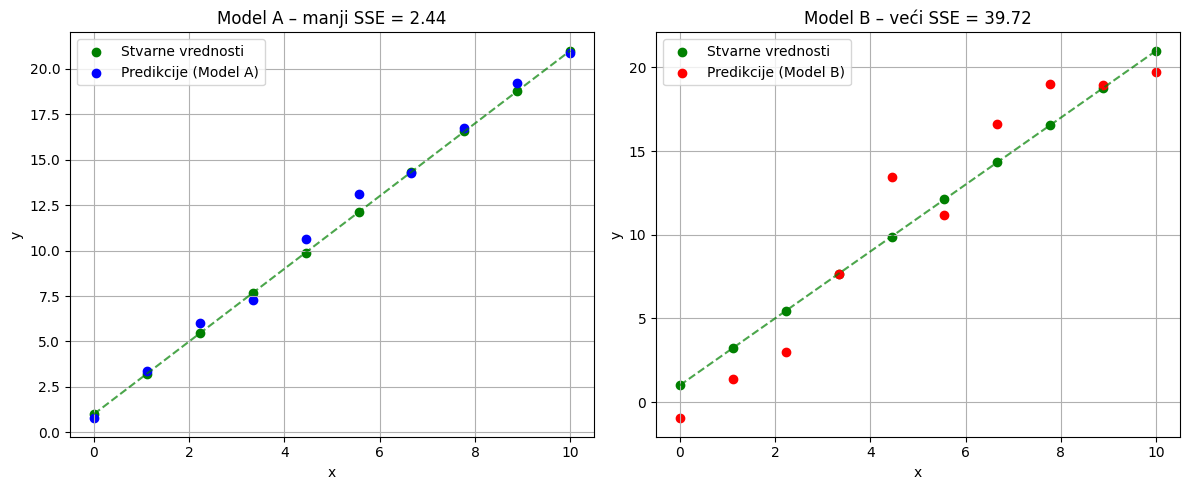

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas

# Stvarne vrednosti
x = np.linspace(0, 10, 10)
y_true = 2 * x + 1  # prava linija

# Model A – tačne predikcije (mali SSE)
y_pred_a = y_true + np.random.normal(0, 0.5, size=len(x))

# Model B – lošije predikcije (veći SSE)
y_pred_b = y_true + np.random.normal(0, 2.0, size=len(x))

# Izračun SSE za oba modela
sse_a = np.sum((y_true - y_pred_a) ** 2)
sse_b = np.sum((y_true - y_pred_b) ** 2)

# Prikaz grafikona
plt.figure(figsize=(12, 5))

# Model A
plt.subplot(1, 2, 1)
plt.scatter(x, y_true, color='green', label='Stvarne vrednosti')
plt.scatter(x, y_pred_a, color='blue', label='Predikcije (Model A)')
plt.plot(x, y_true, 'g--', alpha=0.7)
plt.title(f"Model A – manji SSE = {sse_a:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# Model B
plt.subplot(1, 2, 2)
plt.scatter(x, y_true, color='green', label='Stvarne vrednosti')
plt.scatter(x, y_pred_b, color='red', label='Predikcije (Model B)')
plt.plot(x, y_true, 'g--', alpha=0.7)
plt.title(f"Model B – veći SSE = {sse_b:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Zadaci

**1)** Implementirati jednostavnu linearnu regresiju. Ulazni parametri su liste/vektori *x* i *y*, koji predstavljaju podatke, a povratne vrednosti su *slope* i *intercept* koji predstavlju nagib i presečnu tačku linije koja najbolje "fituje" podatke. Funkcija `fit(x, y)`.

**2)** Implementirati predviđanje vrednosti y na osnovu jednog podatka x koristeci nagib i presek. Funkcija `predict(x, slope, intercept)`.

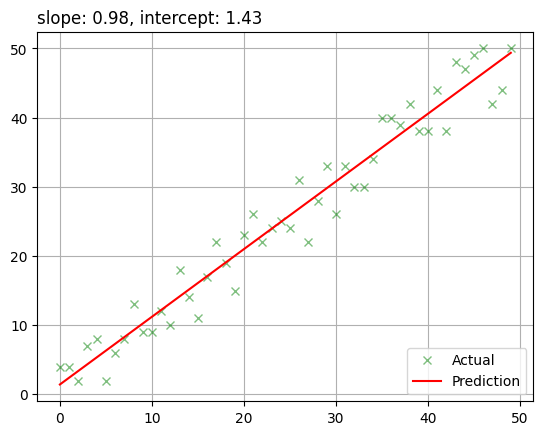

In [19]:
import random
import matplotlib.pyplot as plt


def fit(x, y):
    assert len(x) == len(y)
    assert len(x) != 0

    n = len(x)

    y_mean = sum(y) / n
    x_mean = sum(x) / n

    # Brojilac
    num = 0.0
    # Imenilac
    den = 0.0

    for xi, yi in zip(x, y):
        dx = xi - x_mean
        dy = yi - y_mean
        num += dx * dy
        den += dx * dx

    if den == 0:
        raise ValueError("Cannon fit linear regression when all values of x are the same")

    slope = num / den
    intercept = y_mean - slope * x_mean
    return slope, intercept


def predict(x, slope, intercept):
    # 2) prediktuj vrednosti y na osnovu jednog podatka x koristeci nagib i presek
    return slope * x + intercept


def make_predictions(x, slope, intercept):
    y_pred = [predict(xi, slope, intercept) for xi in x]
    return y_pred


if __name__ == '__main__':
    # da rezultati mogu da se reprodukuju
    random.seed(1337)
    # random generisi podatke sa nasumicnim sumom
    x = [xi for xi in range(50)]
    # y = x (+- nasumicni sum)
    y = [(xi + random.randint(-5, 5)) for xi in x]  

    # izracunaj nagib i presek za liniju koja se najbolja uklapa (best fit)
    slope, intercept = fit(x, y)

    # prediktuj y za svako x
    y_pred = make_predictions(x, slope, intercept)

    # plotuj podatke i liniju koja se nabolje uklapa (best fit)
    plt.plot(x, y, 'xg', alpha=0.5)
    plt.plot(x, y_pred, 'r')
    plt.title(f'slope: {slope:.2f}, intercept: {intercept:.2f}', loc='left')
    plt.legend(['Actual', 'Prediction'], loc='lower right')
    plt.grid(True)


    plt.show()


**3)** Izvršiti linearnu regresiju na primeru predviđanja stope smrtnosti od raka kože na osnovu geografske širine američkih država.
* Učitati datoteku *data/skincancer.csv* i implementirati primenu linearne regresije.
* Iscrati grafik za ovaj slučaj.
* Probati linearnu regresiju nad ovim istim skupom podataka, ali da se umesto geografske širine koristi geografska dužina.

**4)** Primer iz **3)** rešiti pomoću [scikit-learn](https://scikit-learn.org) biblioteke.

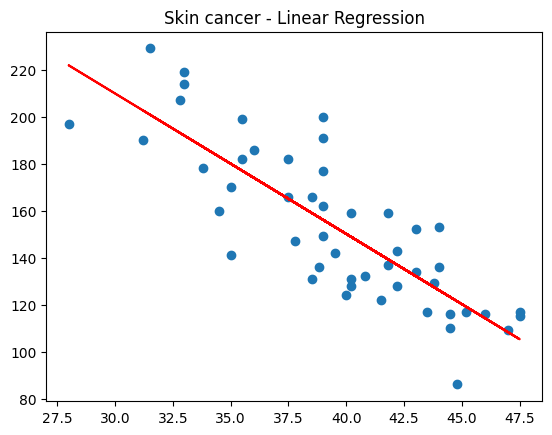

In [36]:
# 3)
import pandas
import matplotlib.pyplot as plt
from scipy import stats

data = pandas.read_csv("./data/skincancer.csv")

data.head(3)
x = data.get('Lat')
y = data.get('Mort')

slope, intercept, r, p, std_err = stats.linregress(x, y)

def predict(x, slope, intercept):
    return slope * x + intercept

model = [predict(xi, slope, intercept) for xi in x]

plt.scatter(x, y)
plt.plot(x, model, 'r')
plt.title("Skin cancer - Linear Regression")
plt.show()

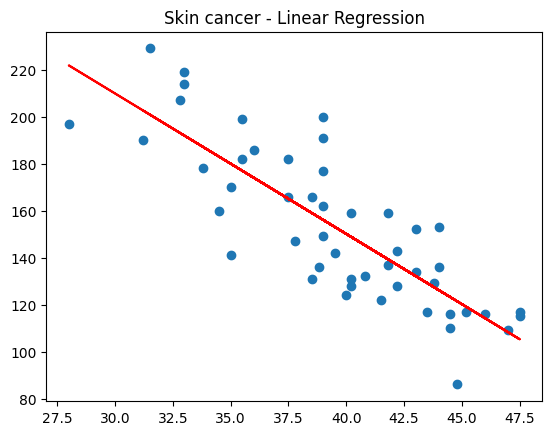

In [48]:
# 4)
from sklearn.linear_model import LinearRegression
import pandas

data = pandas.read_csv("./data/skincancer.csv")

data.head(3)
x = data[['Lat']]
y = data[['Mort']]

reg = LinearRegression().fit(x,y)

model = reg.predict(x)

plt.scatter(x, y)
plt.plot(x, model, 'r')
plt.title("Skin cancer - Linear Regression")
plt.show()